### <font color="green">Importing Dependencies</font>

In [1]:
import sys
print(sys.executable)

C:\MLProject\venv\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import warnings
warnings.filterwarnings('ignore')

### <font color="green">Data Collection & Processing</font>

In [7]:
calories = pd.read_csv("data/calories.csv")

In [8]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [15]:
exercise = pd.read_csv("data/exercise.csv")

In [16]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


### <font color="green">Combining the two Dataframes</font>

In [17]:
calories_data = pd.concat([exercise, calories['Calories']], axis=1)

In [19]:
calories_data.to_csv('calories_data.csv', index=False)

In [20]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [22]:
calories_data.shape

(15000, 9)

In [23]:
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [24]:
calories_data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [25]:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


### <font color="green">Data Analysis</font>

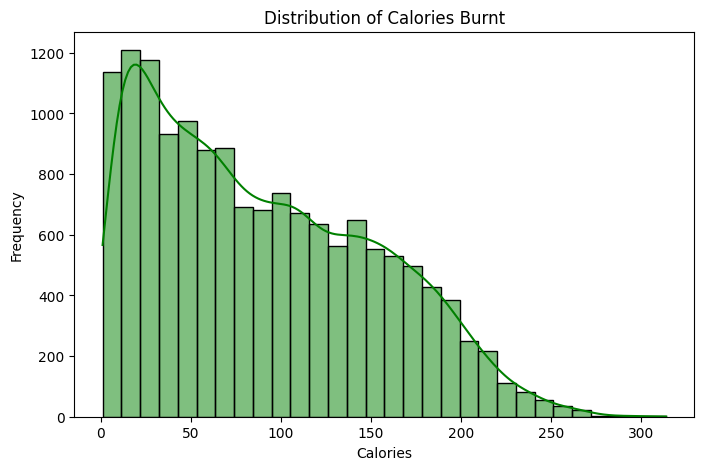

In [29]:
# Distribution of Calories
plt.figure(figsize=(8, 5))
sns.histplot(calories_data['Calories'], bins=30, kde=True, color='green')
plt.title('Distribution of Calories Burnt')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

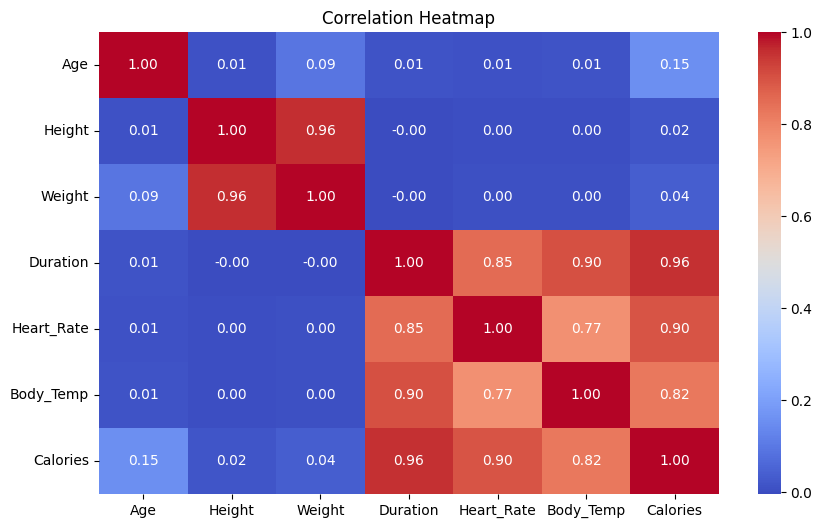

In [31]:
# Correlation heatmap for numerical columns
plt.figure(figsize=(10,6))
numerical_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
sns.heatmap(calories_data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

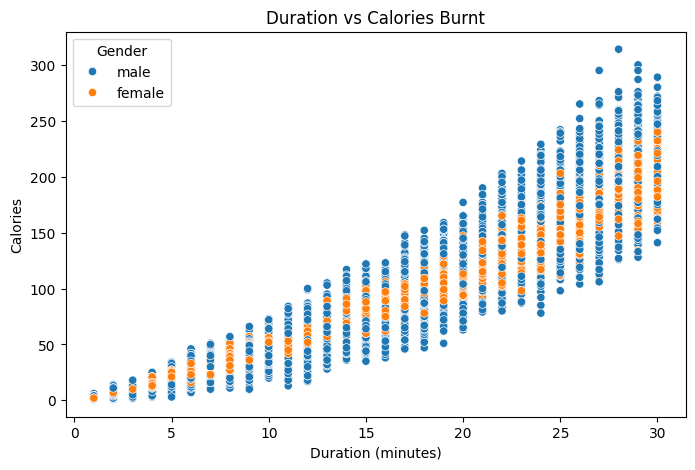

In [33]:
# Scatter plot of Duration vs Calories
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration', y='Calories', hue='Gender', data=calories_data)
plt.title('Duration vs Calories Burnt')
plt.xlabel('Duration (minutes)')
plt.ylabel('Calories')
plt.show()

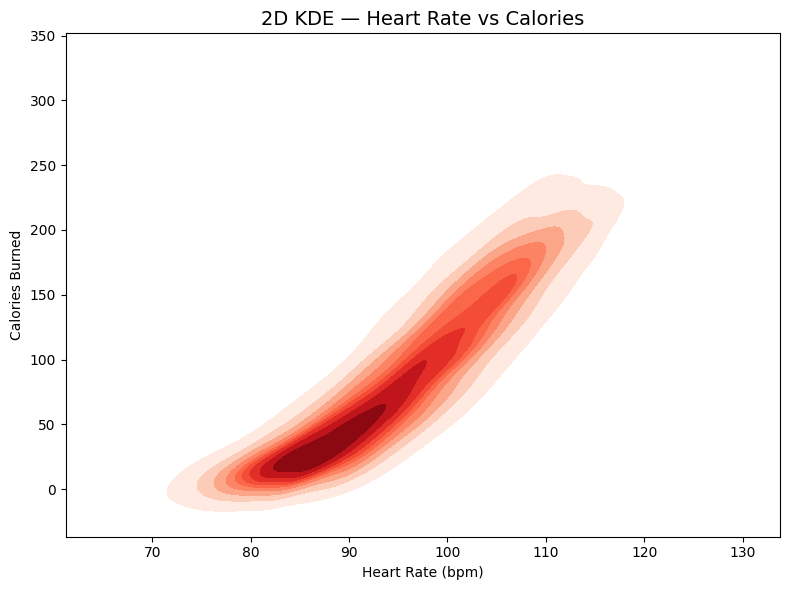

In [35]:
# 2D KDE Plot: Heart Rate vs Calories
fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(
    data=calories_data,
    x="Heart_Rate",
    y="Calories",
    fill=True,
    cmap="Reds",
    thresh=0.05,     
    levels=10,       
    ax=ax
)
ax.set_title("2D KDE — Heart Rate vs Calories", fontsize=14)
ax.set_xlabel("Heart Rate (bpm)")
ax.set_ylabel("Calories Burned")

plt.tight_layout()
plt.savefig("kde_heartrate_calories.png", dpi=150)
plt.show()

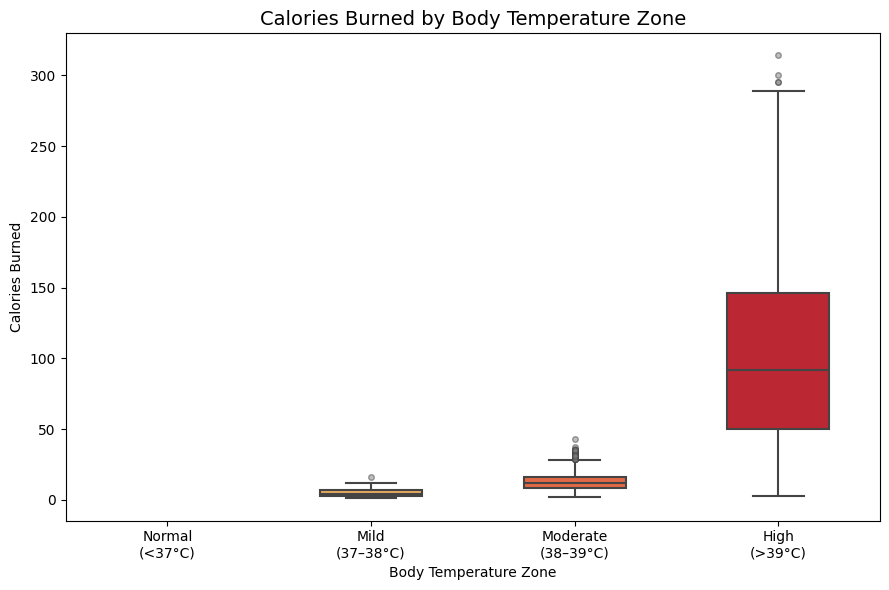

In [36]:
calories_data["Temp_Zone"] = pd.cut(
    calories_data["Body_Temp"],
    bins=[0, 37.0, 38.0, 39.0, 100],
    labels=["Normal\n(<37°C)", "Mild\n(37–38°C)", "Moderate\n(38–39°C)", "High\n(>39°C)"]
)

# Box plot
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=calories_data,
    x="Temp_Zone",
    y="Calories",
    palette="YlOrRd",   
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=4, alpha=0.5),
    ax=ax
)
ax.set_title("Calories Burned by Body Temperature Zone", fontsize=14)
ax.set_xlabel("Body Temperature Zone")
ax.set_ylabel("Calories Burned")

plt.tight_layout()
plt.savefig("boxplot_bodytemp_calories.png", dpi=150)
plt.show()